# URL-only feature extraction + visualizations

## Preprocessing

In [6]:
import sys
from pathlib import Path

# Allow imports from ../src when running from notebooks/
sys.path.append(str(Path('..').resolve() / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from hf_phishing_url.constants import DATASET_ID, LABEL_COL
from hf_phishing_url.data import map_labels
from hf_phishing_url.experiment import load_default_splits
from hf_phishing_url.feature_extraction import UrlFeatureExtractor, UrlTokenizer

RANDOM_STATE = 42
VAL_SIZE = 0.2

pd.set_option('display.max_columns', 200)


In [7]:
# 1) Load original data
splits = load_default_splits(dataset_id=DATASET_ID)
train_raw = splits.train.copy()
print('Dataset:', DATASET_ID)
print('Raw train shape:', train_raw.shape)
display(train_raw.head(3))


Dataset: pirocheto/phishing-url
Raw train shape: (7658, 89)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,nb_underscore,nb_tilde,nb_percent,nb_slash,nb_star,nb_colon,nb_comma,nb_semicolumn,nb_dollar,nb_space,nb_www,nb_com,nb_dslash,http_in_path,https_token,ratio_digits_url,ratio_digits_host,punycode,port,tld_in_path,tld_in_subdomain,abnormal_subdomain,nb_subdomains,prefix_suffix,random_domain,shortening_service,path_extension,nb_redirection,nb_external_redirection,length_words_raw,char_repeat,shortest_words_raw,shortest_word_host,shortest_word_path,longest_words_raw,longest_word_host,longest_word_path,avg_words_raw,avg_word_host,avg_word_path,phish_hints,domain_in_brand,brand_in_subdomain,brand_in_path,suspecious_tld,statistical_report,nb_hyperlinks,ratio_intHyperlinks,ratio_extHyperlinks,ratio_nullHyperlinks,nb_extCSS,ratio_intRedirection,ratio_extRedirection,ratio_intErrors,ratio_extErrors,login_form,external_favicon,links_in_tags,submit_email,ratio_intMedia,ratio_extMedia,sfh,iframe,popup_window,safe_anchor,onmouseover,right_clic,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,https://www.todayshomeowner.com/how-to-make-ho...,82,23,0,2,7,0,0,0,0,0,0,0,0,4,0,1,0,0,0,0,1,0,0,0,0,0.000000,0.0,0,0,0,0,0,2,0,0,0,0,1,0,10,3,2,3,2,15,15,12,6.000000,9.0,5.2500,0,0,0,0,0,0,502,0.918327,0.081673,0,2,0,0.146341,0,0.097561,0,1,28.571429,0,99.170124,0.829876,0,0,0,89.539749,0,0,0,1,1,0,240,8892,67860,0,1,4,legitimate
1,http://thapthan.ac.th/information/confirmation...,93,14,1,2,0,0,0,0,0,0,0,0,0,7,0,1,0,0,0,0,0,0,0,0,1,0.258065,0.0,0,0,0,0,0,2,0,0,0,0,1,0,6,3,4,8,4,32,8,32,12.500000,8.0,13.4000,0,0,0,0,0,0,12,0.916667,0.083333,0,0,0,0.000000,0,0.000000,0,0,83.333333,0,100.000000,0.000000,0,0,0,0.000000,0,0,0,1,0,1,0,2996,4189860,0,1,2,phishing
2,http://app.dialoginsight.com/T/OFC4/L2S/3888/B...,121,21,1,3,0,0,0,0,0,0,0,0,0,17,0,1,0,0,0,0,0,0,0,0,1,0.371901,0.0,0,0,0,0,0,3,0,0,1,0,3,0,18,5,1,3,1,13,13,8,5.166667,8.0,4.8125,1,0,0,0,0,0,83,0.614458,0.385542,0,1,0,0.187500,0,0.000000,0,1,92.307692,0,100.000000,0.000000,0,0,0,9.375000,0,0,0,1,1,0,30,2527,346022,0,1,3,phishing


In [8]:
# 2) Preserve URL + label only
base = train_raw[['url', LABEL_COL]].copy()
display(base.head(5))


,url,status
0,https://www.todayshomeowner.com/how-to-make-ho...,legitimate
1,http://thapthan.ac.th/information/confirmation...,phishing
2,http://app.dialoginsight.com/T/OFC4/L2S/3888/B...,phishing
3,https://www.bedslide.com,legitimate
4,https://tabs.ultimate-guitar.com/s/sex_pistols...,legitimate


In [9]:
# Tokenization visualization: top tokens by class (raw tokens)
tokenizer = UrlTokenizer()

url = base.iloc[0]['url']

toks = tokenizer.tokenize(url)
display(toks)

{'normalized': 'https://www.todayshomeowner.com/how-to-make-homemade-insecticidal-soap-for-plants/',
 'hostname': 'www.todayshomeowner.com',
 'raw_lower': 'https://www.todayshomeowner.com/how-to-make-homemade-insecticidal-soap-for-plants/',
 'host_lower': 'www.todayshomeowner.com',
 'path_lower': '/how-to-make-homemade-insecticidal-soap-for-plants/',
 'raw_tokens': ['https',
  'www',
  'todayshomeowner',
  'com',
  'how',
  'to',
  'make',
  'homemade',
  'insecticidal',
  'soap',
  'for',
  'plants'],
 'host_tokens': ['www', 'todayshomeowner', 'com'],
 'path_tokens': ['how',
  'to',
  'make',
  'homemade',
  'insecticidal',
  'soap',
  'for',
  'plants'],
 'subdomain_tokens': ['www'],
 'tld': 'com'}

In [17]:
# 3) Feature extraction from raw URLs
extractor = UrlFeatureExtractor()

attr = extractor.extract_one(url)
features = extractor.extract_many(base['url'].astype(str).tolist())

df = pd.concat([base, features.drop(columns=['url'])], axis=1)

display(attr)
display(df.head(10))

{'url': 'https://www.todayshomeowner.com/how-to-make-homemade-insecticidal-soap-for-plants/',
 'length_url': 82,
 'length_hostname': 23,
 'ip': 0,
 'nb_dots': 2,
 'nb_hyphens': 7,
 'nb_at': 0,
 'nb_qm': 0,
 'nb_and': 0,
 'nb_or': 0,
 'nb_eq': 0,
 'nb_underscore': 0,
 'nb_tilde': 0,
 'nb_percent': 0,
 'nb_slash': 4,
 'nb_star': 0,
 'nb_colon': 1,
 'nb_comma': 0,
 'nb_semicolumn': 0,
 'nb_dollar': 0,
 'nb_space': 0,
 'nb_www': 1,
 'nb_com': 1,
 'nb_dslash': 1,
 'nb_subdomains': 1,
 'ratio_digits_url': 0.0,
 'ratio_digits_host': 0.0,
 'http_in_path': 0,
 'tld_in_path': 0,
 'tld_in_subdomain': 0,
 'prefix_suffix': 0,
 'path_extension': 0,
 'shortest_words_raw': 2,
 'shortest_word_host': 3,
 'shortest_word_path': 2,
 'longest_words_raw': 15,
 'longest_word_host': 15,
 'longest_word_path': 12,
 'brand_in_subdomain': 0,
 'brand_in_path': 0}

,url,status,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,nb_underscore,nb_tilde,nb_percent,nb_slash,nb_star,nb_colon,nb_comma,nb_semicolumn,nb_dollar,nb_space,nb_www,nb_com,nb_dslash,nb_subdomains,ratio_digits_url,ratio_digits_host,http_in_path,tld_in_path,tld_in_subdomain,prefix_suffix,path_extension,shortest_words_raw,shortest_word_host,shortest_word_path,longest_words_raw,longest_word_host,longest_word_path,brand_in_subdomain,brand_in_path
0,https://www.todayshomeowner.com/how-to-make-ho...,legitimate,82,23,0,2,7,0,0,0,0,0,0,0,0,4,0,1,0,0,0,0,1,1,1,1,0.000000,0.0,0,0,0,0,0,2,3,2,15,15,12,0,0
1,http://thapthan.ac.th/information/confirmation...,phishing,93,14,0,2,0,0,0,0,0,0,0,0,0,7,0,1,0,0,0,0,0,0,1,1,0.258065,0.0,0,0,0,0,0,2,2,4,32,8,32,0,0
2,http://app.dialoginsight.com/T/OFC4/L2S/3888/B...,phishing,121,21,0,3,0,0,0,0,0,0,0,0,0,17,0,1,0,0,0,0,0,1,1,1,0.371901,0.0,0,0,0,0,1,1,3,1,13,13,8,0,0
3,https://www.bedslide.com,legitimate,24,16,0,2,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,1,1,1,1,0.000000,0.0,0,0,0,0,0,3,3,0,8,8,0,0,0
4,https://tabs.ultimate-guitar.com/s/sex_pistols...,legitimate,73,24,0,3,1,0,0,0,0,0,5,0,0,5,0,1,0,0,0,0,0,1,1,1,0.000000,0.0,0,0,0,1,1,1,3,1,8,8,7,0,0
5,http://netarafta.com/fresh/onedri/one/index.php,phishing,47,13,0,2,0,0,0,0,0,0,0,0,0,6,0,1,0,0,0,0,0,1,1,0,0.000000,0.0,0,0,0,0,1,3,3,3,9,9,6,0,0
6,http://stpaulsdillsburg.com/administrator/imag...,phishing,66,20,0,2,0,0,0,0,0,0,0,0,0,6,0,1,0,0,0,0,0,1,1,0,0.000000,0.0,0,0,0,0,1,3,3,3,16,16,13,0,1
7,https://forums.digitalpoint.com/threads/how-to...,legitimate,80,23,0,3,6,0,0,0,0,0,0,0,0,5,0,1,0,0,0,0,0,1,1,1,0.087500,0.0,0,0,0,0,0,2,3,2,12,12,7,0,0
8,http://www.calculatorsoup.com/calculators/math...,legitimate,56,22,0,3,0,0,0,0,0,0,0,0,0,5,0,1,0,0,0,0,1,1,1,1,0.000000,0.0,0,0,0,0,1,3,3,3,14,14,11,0,0
9,https://magalu-crediarioluiza.com/Produto_2020...,phishing,71,25,0,2,1,0,1,0,0,1,1,0,0,4,0,1,0,0,0,0,0,1,1,0,0.169014,0.0,0,0,0,1,1,3,3,3,14,14,7,0,0


In [11]:
# Null values in extracted features
nulls = df.isna().sum().sort_values(ascending=False)
nulls = nulls[nulls > 0]
print(f'Columns with nulls: {len(nulls)}')
display(nulls.head(30))


Columns with nulls: 0


Series([], dtype: int64)

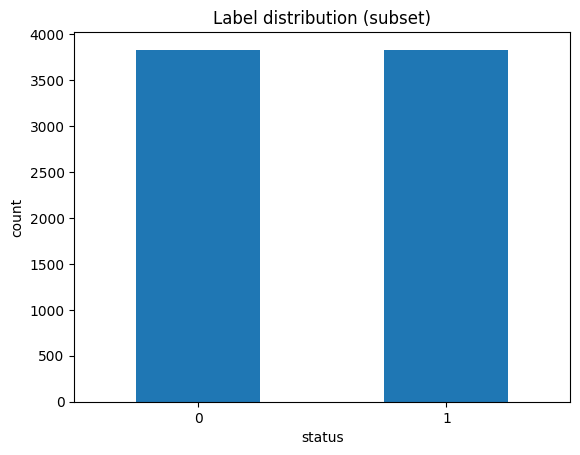

In [12]:
# Label distribution (in the subset)
mapped = map_labels(df)
counts = mapped[LABEL_COL].value_counts().sort_index()

ax = counts.plot(kind='bar', title='Label distribution (subset)', rot=0)
ax.set_label('status (1 = phishing, 0 = legitimate)')
ax.set_ylabel('count')
plt.show()


## Training Model

<Figure size 700x600 with 0 Axes>

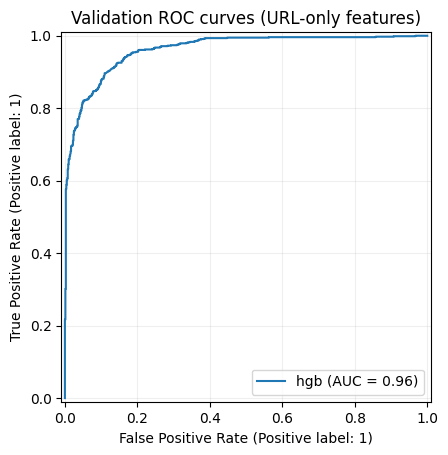

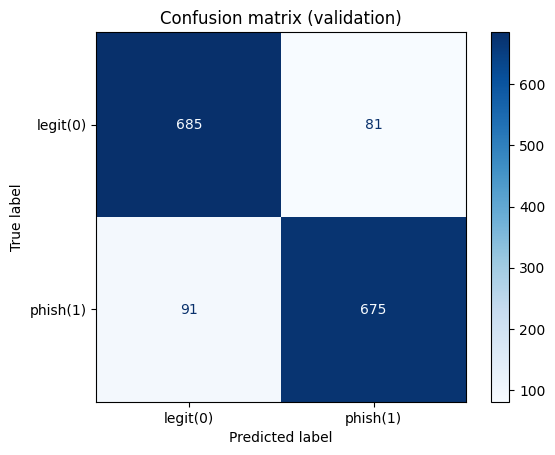

,model,roc_auc,accuracy,f1,precision,recall
0,hgb,0.961867,0.887728,0.886991,0.892857,0.881201


In [13]:
# Train/val split + ROC/AUC visualization (URL-only features)
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

X = mapped.drop(columns=['url', LABEL_COL])
y = mapped[LABEL_COL]

X_tr, X_val, y_tr, y_val = train_test_split(
    X,
    y,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('X_train shape: ', X_tr.shape)
print('y_train shape: ', y_tr.shape)

candidate = [
    (
        'hgb',
        Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('clf', HistGradientBoostingClassifier(
                random_state=RANDOM_STATE,
                max_depth=None,
                learning_rate=0.1,
            )),
        ]),
    ),
]

rows = []
y_pred = []
plt.figure(figsize=(7, 6))

for name, model in candidate:
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_val)[:, 1]
    else:
        scores = model.decision_function(X_val)
        y_score = 1 / (1 + np.exp(-scores))

    rows.append({
        'model': name,
        'roc_auc': float(roc_auc_score(y_val, y_score)),
        'accuracy': float(accuracy_score(y_val, y_pred)),
        'f1': float(f1_score(y_val, y_pred)),
        'precision': float(precision_score(y_val, y_pred)),
        'recall': float(recall_score(y_val, y_pred)),
    })

    RocCurveDisplay.from_predictions(y_val, y_score, name=name)

plt.title('Validation ROC curves (URL-only features)')
plt.grid(True, alpha=0.2)
plt.show()

cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['legit(0)', 'phish(1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion matrix (validation)')
plt.grid(False)
plt.show()

metrics_df = pd.DataFrame(rows).sort_values('roc_auc', ascending=False)
display(metrics_df)
